# DCIR Simulation with PyBaMM

This notebook demonstrates how to perform Direct Current Internal Resistance (DCIR) simulation using PyBaMM with BYD Blade Prismatic 135Ah cell parameters.

## Overview
- **Cell**: BYD Blade Prismatic 135Ah LFP
- **Chemistry**: LFP (Lithium Iron Phosphate)
- **Form Factor**: Prismatic
- **Nominal Voltage**: 3.3V
- **Capacity**: 135Ah
- **Simulations**: DCIR (7 time points)

In [2]:
# Import required libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model_library import run_spmet
from model_library.spmet_dcir import simulate_dcir

AttributeError: module 'matplotlib' has no attribute 'get_data_path'

## 1. Load Cell Parameters

Load the cell design from the manifest file.

In [ ]:
# Load cell manifest
manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
material_path = Path("../materials")
# manifest_path = Path("../cells/BYD_Blade_Prismatic_135Ah_manifest.json")

with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)
    # Load material data for separator and electrolyte
    for component in ["separator", "electrolyte"]:
        print(f"Loading material data for {component}") 
        material_name = cell_design_manifest["cell_design"][component]["material"]["type"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

    # Load material data for electrodes
    for component in ["negative_electrode", "positive_electrode"]:
        print(f"Loading material data for {component}") 
        material_name = cell_design_manifest["cell_design"][component]["coating"]["formulation"]["primary_active_material"]["name"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

nominal_capacity = cell_design_manifest['kpis']['nominal_capacity']['value']
nominal_energy = cell_design_manifest["kpis"]["nominal_energy"]["value"] 
cell_design = cell_design_manifest["cell_design"]
upper_voltage_cutoff = cell_design["upper_voltage_cutoff"][
    "value"
]
lower_voltage_cutoff = cell_design_manifest["cell_design"]["lower_voltage_cutoff"][
    "value"
]
cell_design["nominal_capacity"] = {"value": nominal_capacity, "unit": "Ah"}
cell_design["nominal_energy"] = {"value": nominal_energy, "unit": "Wh"}

cell_design["cell_volume"] = {
    "value": cell_design_manifest['kpis']['cell_volume']['value'],
    "unit": "cm3"
}

Loading material data for separator
Loading material data for electrolyte
Loading material data for negative_electrode
Loading material data for positive_electrode


## 2. Setup PyBaMM Model Parameters

Configure PyBaMM SPMe (Single Particle Model with electrolyte effects) using the cell design parameters.

In [ ]:
dcir_config = {
    "ambient_temperature": 298.15,  # 25C
    "initial_temperature": 298.15,  # 25C
    "contact_resistance": 1e-5,  # Ohms
    "total_heat_transfer_coefficient": 0.01,  # W/m2/K
    "cooling_surface_area": 0.1,  # m2
    "initial_soc": 0.5,  # 50% SOC
    "upper_voltage_cutoff": upper_voltage_cutoff,  # V
    "lower_voltage_cutoff": lower_voltage_cutoff,  # V
    "period": "0.01 second",  # High resolution for DCIR
    "experiments": [
        f"Discharge at 1C for 30 seconds or until {lower_voltage_cutoff} V",
    ],
    "experiment_labels": [f"1C_DCIR"],
}
results = run_spmet(cell_design=cell_design, simulation_config=dcir_config)


Building model parameters from manifest...

CAPACITY CALIBRATION
Target capacity: 161.10 Ah
Convergence tolerance: 0.010%
--------------------------------------------------------------------------------
Iteration  1: Capacity =  60.01 Ah, Error = 62.751%
Iteration  2: Capacity = 163.23 Ah, Error =  1.324%
Iteration  3: Capacity = 161.08 Ah, Error =  0.011%
Iteration  4: Capacity = 161.11 Ah, Error =  0.007%
--------------------------------------------------------------------------------
Converged after 4 iterations!

RUNNING EXPERIMENTS

Running: 1C_DCIR
  Experiment: Discharge at 1C for 30 seconds or until 2.5 V
  Completed: 3001 data points


In [ ]:
# Post-processing: Calculate DCIR from time series
result = results[0]  # Single experiment result

if result['success']:
    time_s = result['time_s']
    voltage_V = result['voltage_V']
    current_A = result['current_A']
    
    # Rest voltage (first point)
    v_rest = voltage_V[0]
    
    # Current amplitude during pulse
    i_amplitude = cell_design_manifest['kpis']['nominal_capacity']['value']
    contact_resistance = dcir_config.get('contact_resistance')
    
    # Calculate DCIR at various time points
    dcir_time_points = [0.01, 0.1, 1.0, 10.0, 30.0]
    dcir_results = []
    
    for t_point in dcir_time_points:
        t_idx = np.argmin(np.abs(time_s - time_s[0] - t_point))
        v_pulse = voltage_V[t_idx]
        dcir_ohm = abs(v_pulse - v_rest) / i_amplitude + contact_resistance
        dcir_mohm = dcir_ohm * 1000
        dcir_results.append({
            'time_s': t_point,
            'dcir_mohm': dcir_mohm,
            'voltage_V': v_pulse
        })
    
    dcir_df = pd.DataFrame(dcir_results)
    print("\nDCIR Results:")
    print(dcir_df.to_string(index=False))
else:
    print(f"Simulation failed: {result.get('error', 'Unknown error')}")


DCIR Results:
 time_s  dcir_mohm  voltage_V
   0.01   0.010122   3.472281
   0.10   0.011201   3.472107
   1.00   0.020968   3.470534
  10.00   0.086332   3.460004
  30.00   0.163863   3.447513


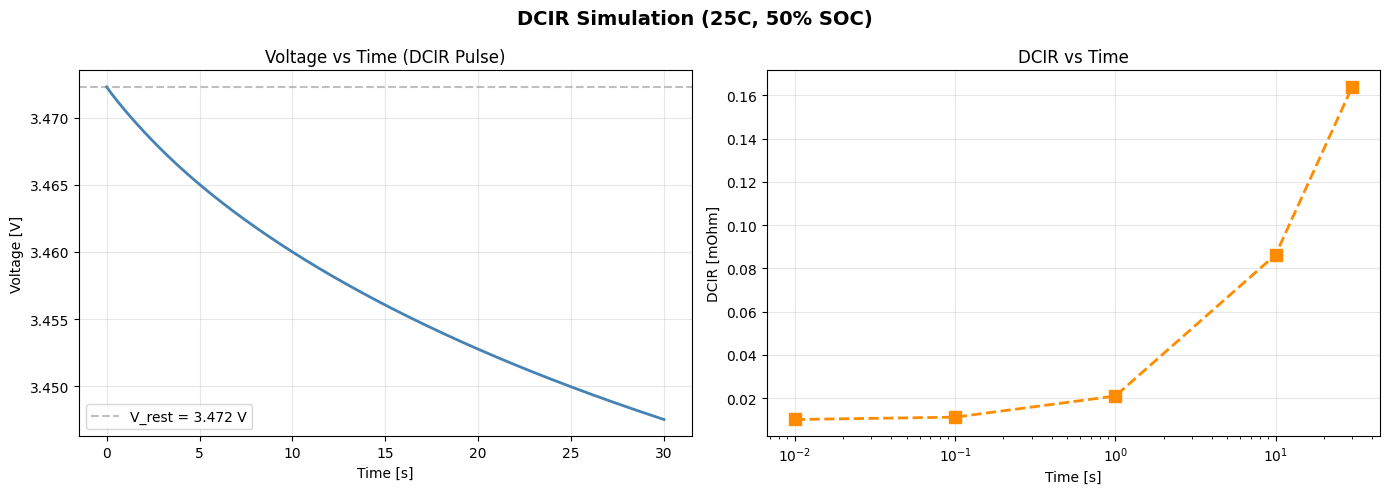

In [ ]:
if result['success']:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Voltage vs Time
    ax1 = axes[0]
    time_plot = time_s - time_s[0]
    ax1.plot(time_plot, voltage_V, linewidth=2, color='steelblue')
    ax1.set_xlabel('Time [s]')
    ax1.set_ylabel('Voltage [V]')
    ax1.set_title('Voltage vs Time (DCIR Pulse)')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=v_rest, color='gray', linestyle='--', alpha=0.5, label=f'V_rest = {v_rest:.3f} V')
    ax1.legend()
    
    # Plot 2: DCIR vs Time
    ax2 = axes[1]
    ax2.plot(dcir_df['time_s'], dcir_df['dcir_mohm'], 's--', linewidth=2, markersize=8, color='darkorange')
    ax2.set_xlabel('Time [s]')
    ax2.set_ylabel('DCIR [mOhm]')
    ax2.set_title('DCIR vs Time')
    ax2.set_xscale('log')
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f'DCIR Simulation ({dcir_config["ambient_temperature"]-273.15:.0f}C, {dcir_config["initial_soc"]*100:.0f}% SOC)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No successful simulation to plot.")

## 3. DCIR Surface: C-rate vs SOC vs Temperature

Generate a comprehensive DCIR surface map across multiple operating conditions using `simulate_dcir` with array inputs:
- **C-rates**: 0.1C, 2C, 10C, 30C
- **SOC**: 10% to 90% (5 levels)
- **Temperature**: 0°C to 45°C (4 levels)

In [ ]:
# Define parameter sweep ranges
c_rates = [0.1, 2, 10, 30]  # C-rates to test
soc_levels = [0.1, 0.3, 0.5, 0.7, 0.9]  # SOC levels (10% to 90%)
temperatures_C = [0, 15, 25, 45]  # Temperatures in Celsius
temperatures_K = [t + 273.15 for t in temperatures_C]

# DCIR measurement time point (seconds after pulse start)
dcir_time_point = 10.0  # 10-second DCIR

# Run DCIR sweep using simulate_dcir with array inputs
dcir_sweep_results = simulate_dcir(
    cell_design=cell_design,
    kpis=cell_design_manifest['kpis'],
    initial_soc=soc_levels,
    temperature_K=temperatures_K,
    c_rate=c_rates,
    contact_resistance=1e-5,
)

print(f"\nSweep completed: {dcir_sweep_results['num_simulations']} simulations")


DCIR SURFACE SWEEP
SOC values: ['10%', '30%', '50%', '70%', '90%']
Temperature values: ['0°C', '15°C', '25°C', '45°C']
C-rate values: [np.float64(0.1), np.float64(2.0), np.float64(10.0), np.float64(30.0)]
Total simulations: 80

Building model parameters from cell design...

CAPACITY CALIBRATION
Target capacity: 161.10 Ah
Convergence tolerance: 0.010%
--------------------------------------------------------------------------------
Iteration  1: Capacity =  60.01 Ah, Error = 62.751%
Iteration  2: Capacity = 163.23 Ah, Error =  1.324%
Iteration  3: Capacity = 161.08 Ah, Error =  0.011%
Iteration  4: Capacity = 161.11 Ah, Error =  0.007%
--------------------------------------------------------------------------------
Converged after 4 iterations!

RUNNING DCIR SWEEP

--- Temperature: 0°C ---
  SOC=10%, C=0.1C: DCIR@10s = 0.346 mΩ
  SOC=10%, C=2.0C: DCIR@10s = 0.401 mΩ


2026-01-27 15:05:28.755 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Discharge at 10.0C for 30.0 seconds'. The returned solution only contains up to step 1 of cycle 2. 


  SOC=10%, C=10.0C: DCIR@10s = 0.714 mΩ


2026-01-27 15:05:29.128 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Discharge at 30.0C for 30.0 seconds'. The returned solution only contains up to step 1 of cycle 2. 


  SOC=10%, C=30.0C: Pulse ended early
  SOC=30%, C=0.1C: DCIR@10s = 0.161 mΩ
  SOC=30%, C=2.0C: DCIR@10s = 0.163 mΩ


...

  SOC=50%, C=30.0C: DCIR@10s = 0.100 mΩ
  SOC=70%, C=0.1C: DCIR@10s = 0.055 mΩ
  SOC=70%, C=2.0C: DCIR@10s = 0.057 mΩ
  SOC=70%, C=10.0C: DCIR@10s = 0.060 mΩ


2026-01-27 15:05:54.510 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Discharge at 30.0C for 30.0 seconds'. The returned solution only contains up to step 1 of cycle 2. 


  SOC=70%, C=30.0C: DCIR@10s = 0.088 mΩ
  SOC=90%, C=0.1C: DCIR@10s = 0.058 mΩ
  SOC=90%, C=2.0C: DCIR@10s = 0.060 mΩ
  SOC=90%, C=10.0C: DCIR@10s = 0.061 mΩ


2026-01-27 15:05:55.884 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Discharge at 30.0C for 30.0 seconds'. The returned solution only contains up to step 1 of cycle 2. 


  SOC=90%, C=30.0C: DCIR@10s = 0.063 mΩ

Completed 80 simulations

Sweep completed: 80 simulations


In [ ]:
# Convert surface_data to DataFrame for plotting
surface_data = dcir_sweep_results['surface_data']

# Extract 10s DCIR values into flat structure for DataFrame
dcir_surface_data = []
for point in surface_data:
    dcir_10s = point['dcir_mOhm'].get(10.0, np.nan)
    dcir_surface_data.append({
        'temperature_C': point['temperature_C'],
        'soc': point['soc'],
        'soc_pct': point['soc_pct'],
        'c_rate': point['c_rate'],
        'dcir_mohm': dcir_10s,
        'success': point['success'],
    })

dcir_surface_df = pd.DataFrame(dcir_surface_data)

# Display summary table
print("\nDCIR Surface Data Summary (10s DCIR):")
pivot_table = dcir_surface_df.pivot_table(
    values='dcir_mohm', 
    index=['temperature_C', 'soc_pct'], 
    columns='c_rate',
    aggfunc='first'
)
print(pivot_table.to_string())

# Export to CSV for further analysis
dcir_surface_df.to_csv('dcir_surface_data.csv', index=False)
print("\nData exported to dcir_surface_data.csv")


DCIR Surface Data Summary (10s DCIR):
c_rate                     0.1       2.0       10.0      30.0
temperature_C soc_pct                                        
0.0           10.0     0.346096  0.400850  0.713833       NaN
              30.0     0.160870  0.163339  0.174806       NaN
              50.0     0.100039  0.104469  0.123524       NaN
              70.0     0.093586  0.094447  0.096320       NaN
              90.0     0.099383  0.099769  0.100650       NaN
15.0          10.0     0.319932  0.374962  0.723208       NaN
              30.0     0.140262  0.144389  0.153238       NaN
              50.0     0.083651  0.088348  0.103647       NaN
              70.0     0.077308  0.078980  0.080409       NaN
              90.0     0.082331  0.083523  0.083283       NaN
25.0          10.0     0.300679  0.357118  0.691006       NaN
              30.0     0.128435  0.132306  0.140308       NaN
              50.0     0.072936  0.078517  0.092006  0.318137
              70.0     0.066833

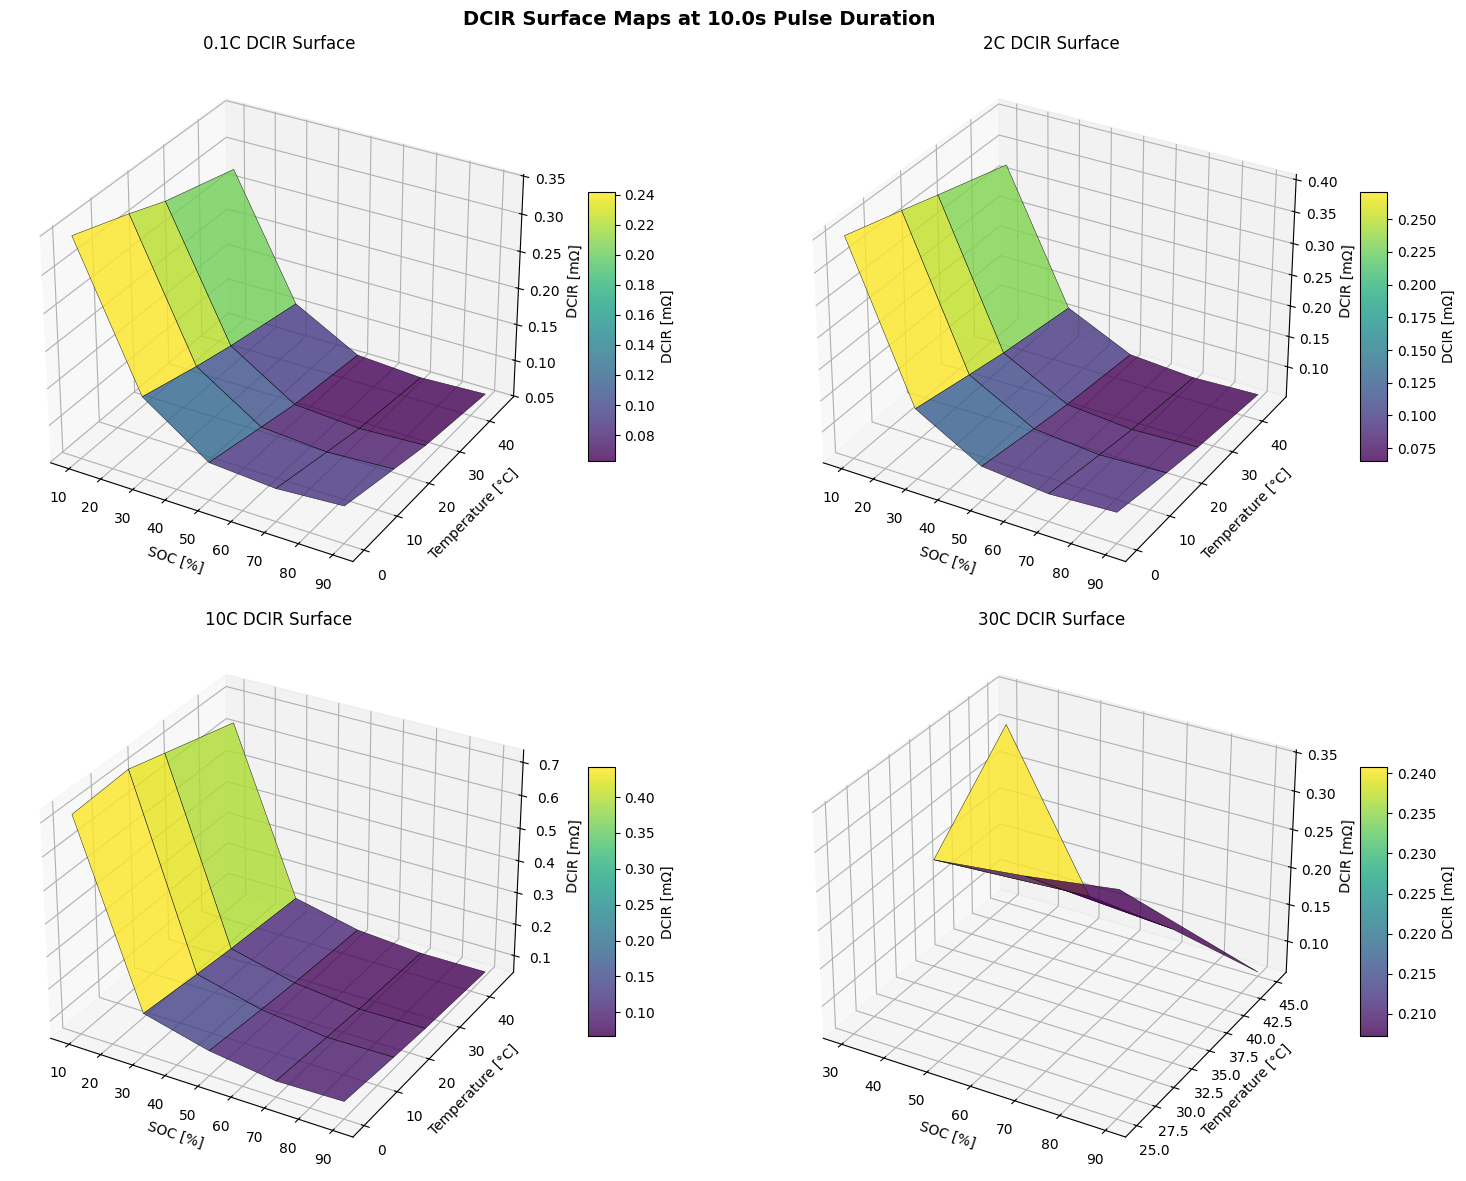

In [ ]:
# Create DCIR surface plots
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

fig = plt.figure(figsize=(16, 12))

# Plot 1: 3D Surface - DCIR vs SOC vs Temperature (for each C-rate)
for idx, c_rate in enumerate(c_rates):
    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')
    
    # Filter data for this C-rate
    c_rate_data = dcir_surface_df[dcir_surface_df['c_rate'] == c_rate].copy()
    c_rate_data = c_rate_data.dropna(subset=['dcir_mohm'])
    
    if len(c_rate_data) > 0:
        # Create meshgrid for surface
        soc_unique = np.sort(c_rate_data['soc_pct'].unique())
        temp_unique = np.sort(c_rate_data['temperature_C'].unique())
        
        # Pivot to create 2D grid
        pivot = c_rate_data.pivot_table(
            values='dcir_mohm',
            index='temperature_C',
            columns='soc_pct',
            aggfunc='first'
        )
        
        SOC, TEMP = np.meshgrid(pivot.columns.values, pivot.index.values)
        DCIR = pivot.values
        
        # Plot surface
        surf = ax.plot_surface(SOC, TEMP, DCIR, cmap=cm.viridis, 
                               edgecolor='k', linewidth=0.3, alpha=0.8)
        
        ax.set_xlabel('SOC [%]')
        ax.set_ylabel('Temperature [°C]')
        ax.set_zlabel('DCIR [mΩ]')
        ax.set_title(f'{c_rate}C DCIR Surface')
        
        # Add colorbar
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='DCIR [mΩ]')
    else:
        ax.text(0.5, 0.5, 0.5, f'No data for {c_rate}C', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{c_rate}C DCIR Surface (No Data)')

plt.suptitle(f'DCIR Surface Maps at {dcir_time_point}s Pulse Duration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

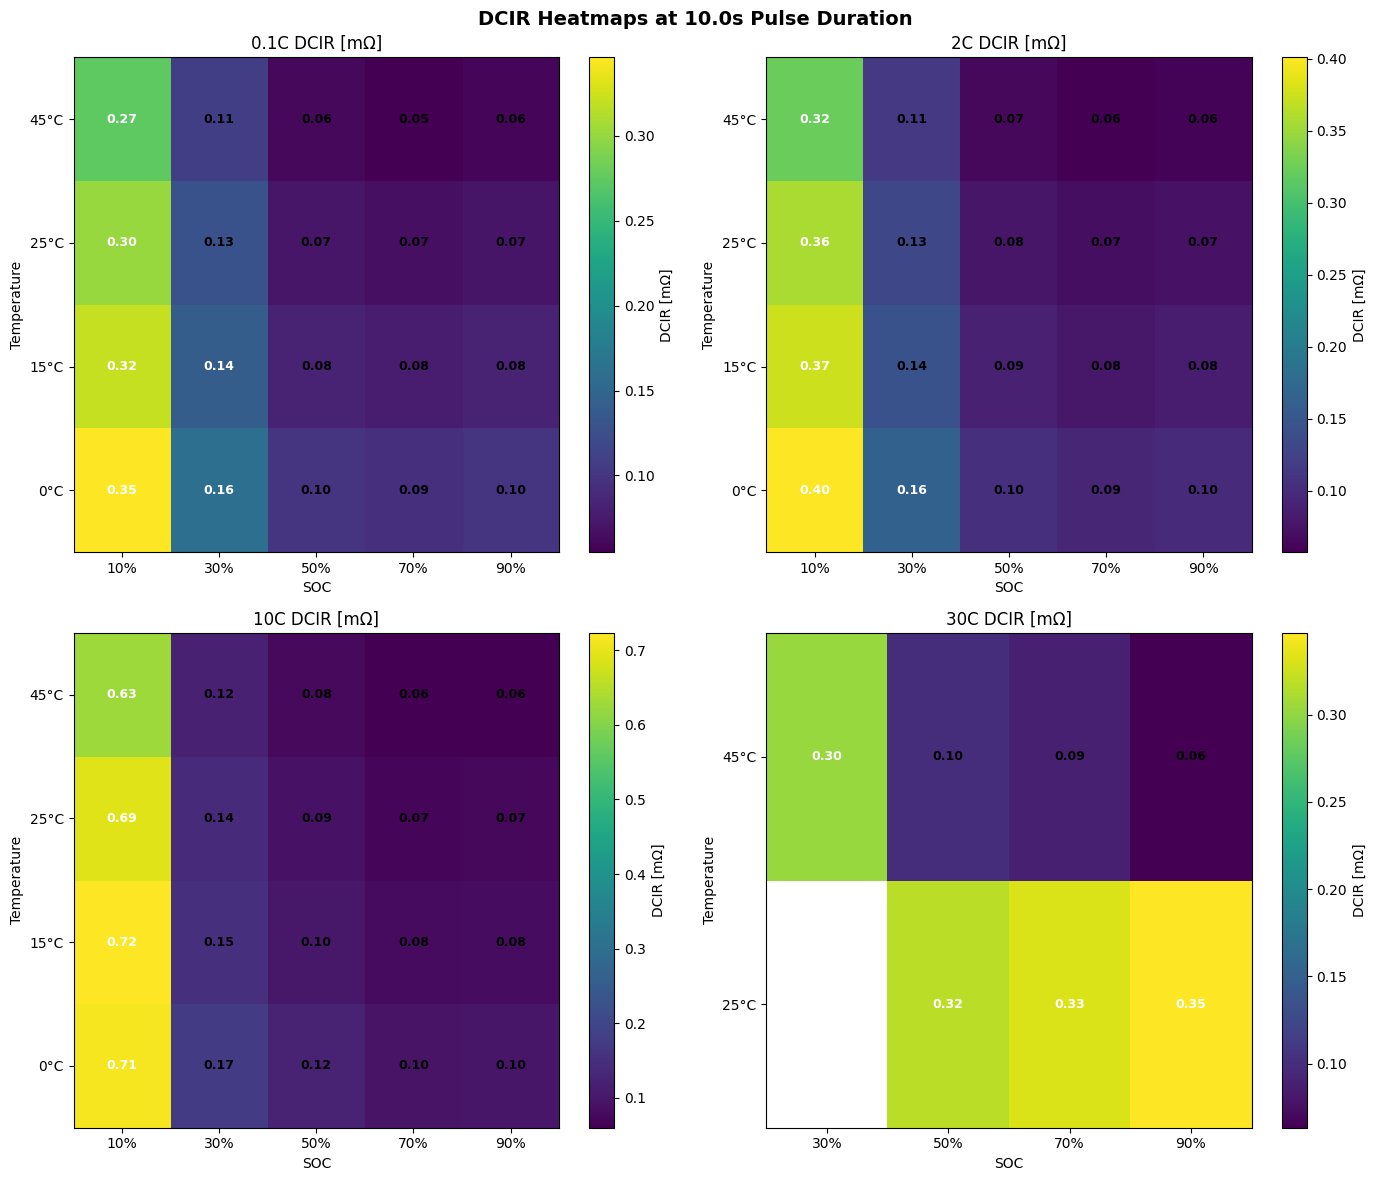

In [ ]:
# 2D Heatmap views for better visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, c_rate in enumerate(c_rates):
    ax = axes[idx // 2, idx % 2]
    
    # Filter data for this C-rate
    c_rate_data = dcir_surface_df[dcir_surface_df['c_rate'] == c_rate].copy()
    
    # Pivot to create heatmap
    pivot = c_rate_data.pivot_table(
        values='dcir_mohm',
        index='temperature_C',
        columns='soc_pct',
        aggfunc='first'
    )
    
    # Plot heatmap
    im = ax.imshow(pivot.values, cmap='viridis', aspect='auto', origin='lower')
    
    # Set tick labels
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{int(s)}%' for s in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{int(t)}°C' for t in pivot.index])
    
    ax.set_xlabel('SOC')
    ax.set_ylabel('Temperature')
    ax.set_title(f'{c_rate}C DCIR [mΩ]')
    
    # Add colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('DCIR [mΩ]')
    
    # Annotate cells with values
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                text_color = 'white' if val > pivot.values[~np.isnan(pivot.values)].mean() else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                       color=text_color, fontsize=9, fontweight='bold')

plt.suptitle(f'DCIR Heatmaps at {dcir_time_point}s Pulse Duration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

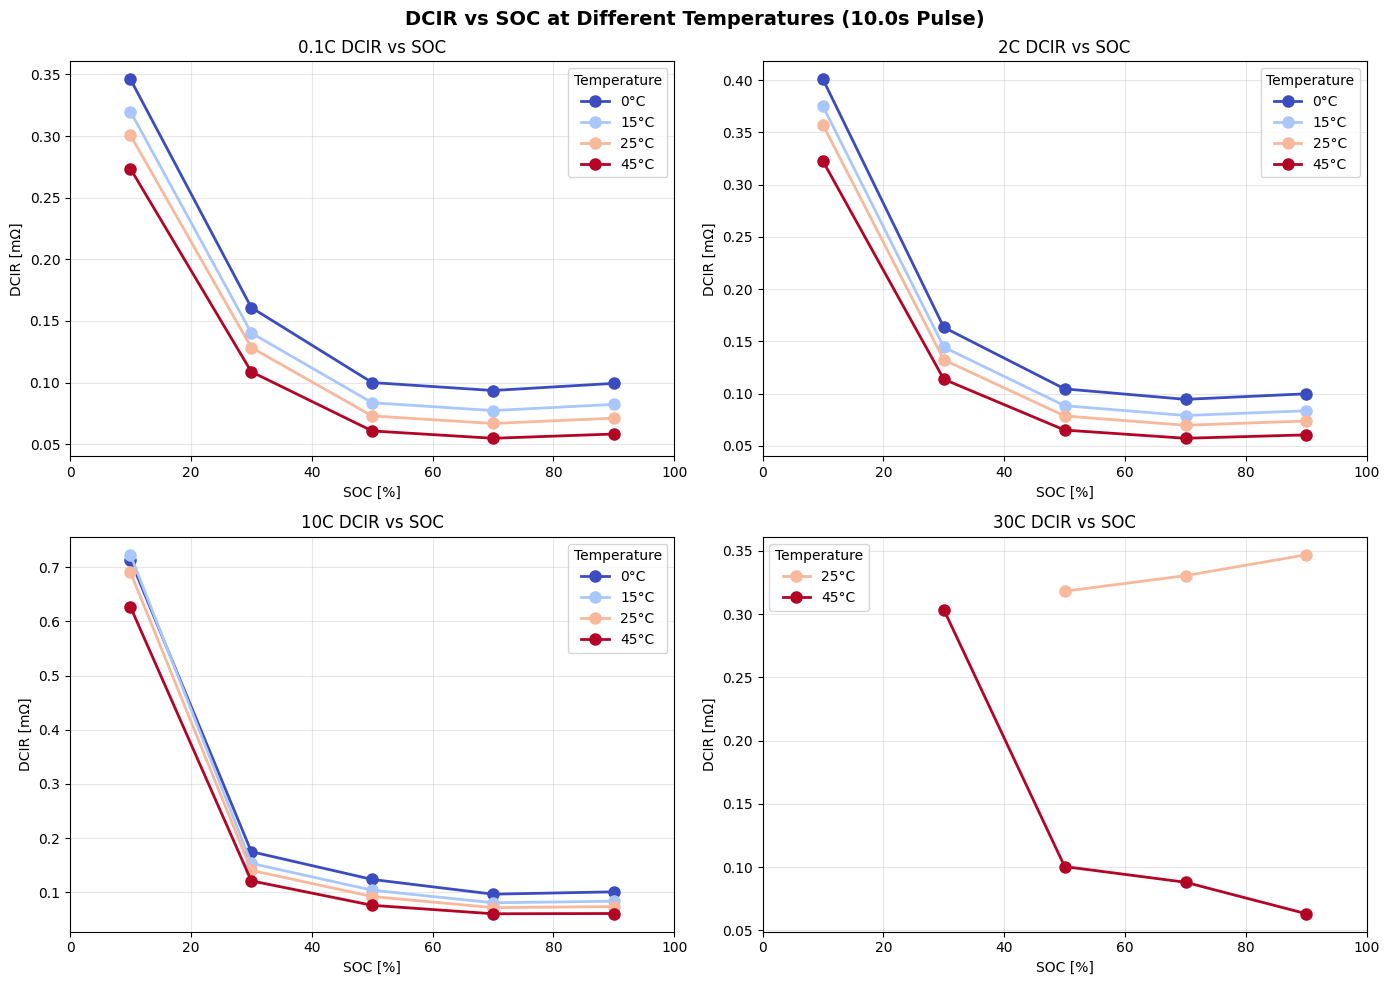

In [ ]:
# Line plots: DCIR vs SOC at different temperatures (one subplot per C-rate)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(temperatures_C)))

for idx, c_rate in enumerate(c_rates):
    ax = axes[idx // 2, idx % 2]
    
    for temp_idx, temp_C in enumerate(temperatures_C):
        # Filter data
        mask = (dcir_surface_df['c_rate'] == c_rate) & (dcir_surface_df['temperature_C'] == temp_C)
        data = dcir_surface_df[mask].sort_values('soc_pct')
        
        if len(data) > 0 and not data['dcir_mohm'].isna().all():
            ax.plot(data['soc_pct'], data['dcir_mohm'], 'o-', 
                   color=colors[temp_idx], linewidth=2, markersize=8,
                   label=f'{temp_C}°C')
    
    ax.set_xlabel('SOC [%]')
    ax.set_ylabel('DCIR [mΩ]')
    ax.set_title(f'{c_rate}C DCIR vs SOC')
    ax.legend(title='Temperature')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 100])

plt.suptitle(f'DCIR vs SOC at Different Temperatures ({dcir_time_point}s Pulse)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

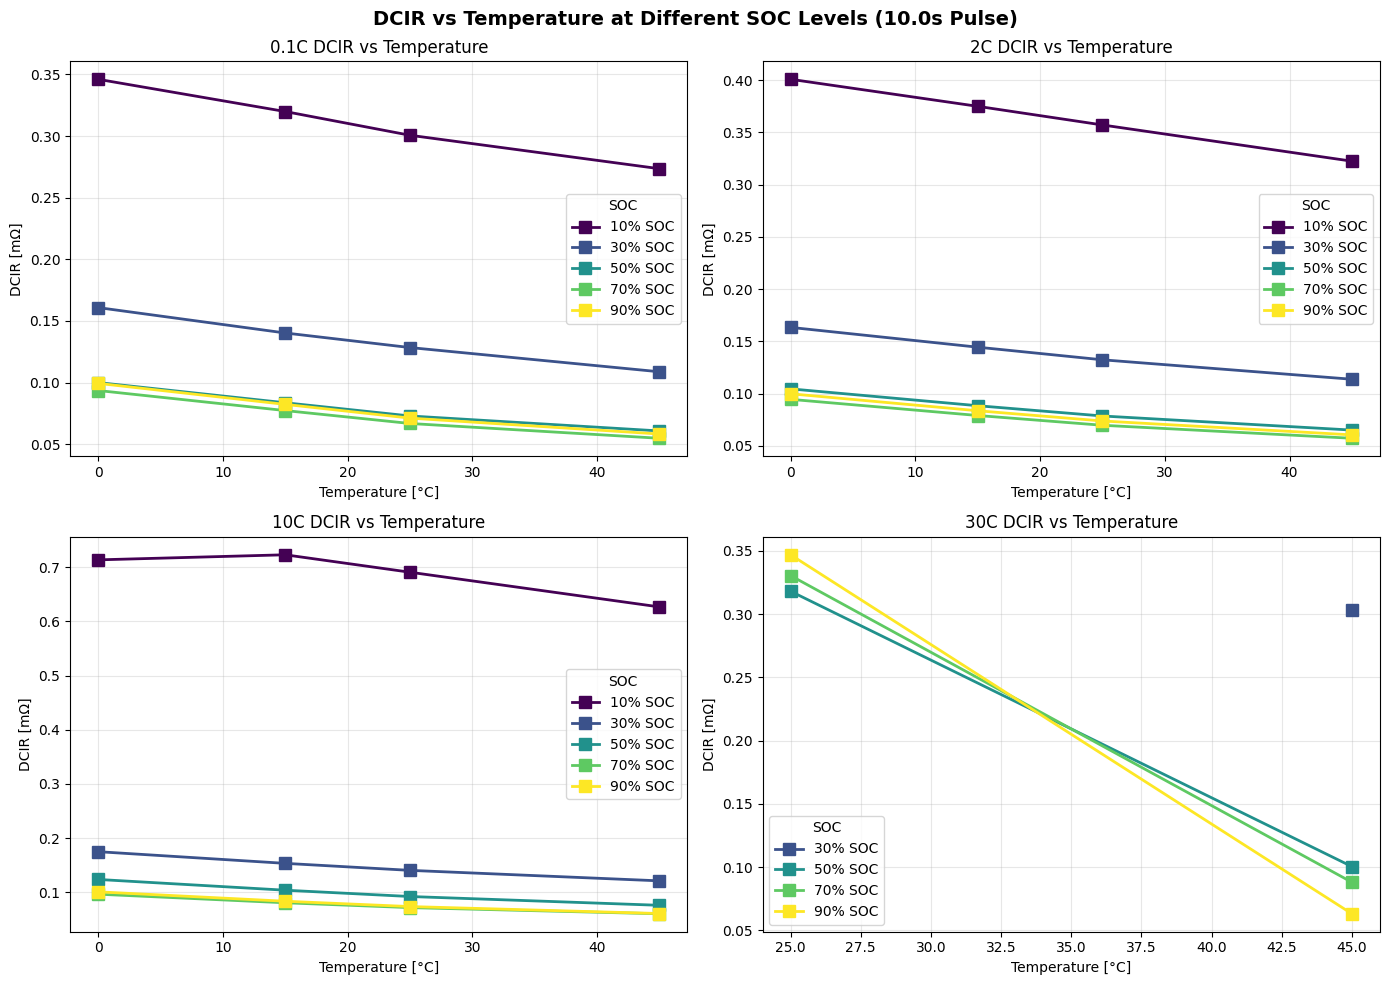

In [ ]:
# Line plots: DCIR vs Temperature at different SOC levels (one subplot per C-rate)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(soc_levels)))

for idx, c_rate in enumerate(c_rates):
    ax = axes[idx // 2, idx % 2]
    
    for soc_idx, soc in enumerate(soc_levels):
        # Filter data
        mask = (dcir_surface_df['c_rate'] == c_rate) & (dcir_surface_df['soc'] == soc)
        data = dcir_surface_df[mask].sort_values('temperature_C')
        
        if len(data) > 0 and not data['dcir_mohm'].isna().all():
            ax.plot(data['temperature_C'], data['dcir_mohm'], 's-', 
                   color=colors[soc_idx], linewidth=2, markersize=8,
                   label=f'{int(soc*100)}% SOC')
    
    ax.set_xlabel('Temperature [°C]')
    ax.set_ylabel('DCIR [mΩ]')
    ax.set_title(f'{c_rate}C DCIR vs Temperature')
    ax.legend(title='SOC')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'DCIR vs Temperature at Different SOC Levels ({dcir_time_point}s Pulse)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

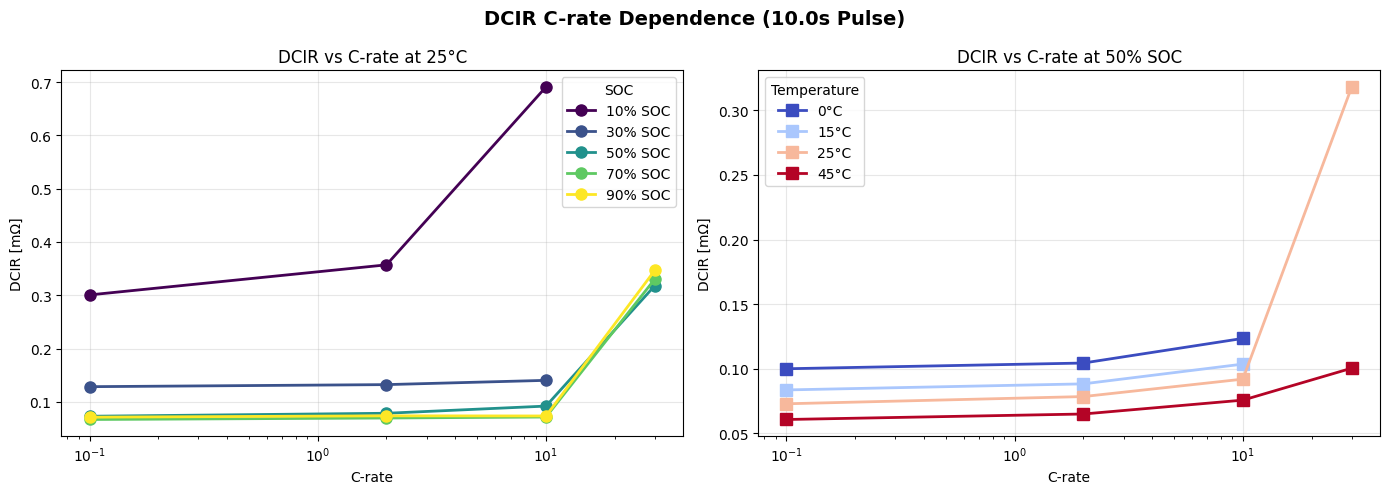

In [ ]:
# C-rate comparison: DCIR vs C-rate at fixed conditions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: DCIR vs C-rate at 25°C for different SOC
ax1 = axes[0]
temp_fixed = 25
colors = plt.cm.viridis(np.linspace(0, 1, len(soc_levels)))

for soc_idx, soc in enumerate(soc_levels):
    mask = (dcir_surface_df['temperature_C'] == temp_fixed) & (dcir_surface_df['soc'] == soc)
    data = dcir_surface_df[mask].sort_values('c_rate')
    
    if len(data) > 0 and not data['dcir_mohm'].isna().all():
        ax1.plot(data['c_rate'], data['dcir_mohm'], 'o-', 
                color=colors[soc_idx], linewidth=2, markersize=8,
                label=f'{int(soc*100)}% SOC')

ax1.set_xlabel('C-rate')
ax1.set_ylabel('DCIR [mΩ]')
ax1.set_title(f'DCIR vs C-rate at {temp_fixed}°C')
ax1.legend(title='SOC')
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# Plot 2: DCIR vs C-rate at 50% SOC for different temperatures
ax2 = axes[1]
soc_fixed = 0.5
colors = plt.cm.coolwarm(np.linspace(0, 1, len(temperatures_C)))

for temp_idx, temp_C in enumerate(temperatures_C):
    mask = (dcir_surface_df['soc'] == soc_fixed) & (dcir_surface_df['temperature_C'] == temp_C)
    data = dcir_surface_df[mask].sort_values('c_rate')
    
    if len(data) > 0 and not data['dcir_mohm'].isna().all():
        ax2.plot(data['c_rate'], data['dcir_mohm'], 's-', 
                color=colors[temp_idx], linewidth=2, markersize=8,
                label=f'{temp_C}°C')

ax2.set_xlabel('C-rate')
ax2.set_ylabel('DCIR [mΩ]')
ax2.set_title(f'DCIR vs C-rate at {int(soc_fixed*100)}% SOC')
ax2.legend(title='Temperature')
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')

plt.suptitle(f'DCIR C-rate Dependence ({dcir_time_point}s Pulse)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()